### Import Packages

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Load Data

In [2]:
file_path = '/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features.csv'
# id_list = '/Users/baselhussein/Projects/impossible_goals/agg/data/ids_evaluation.csv'

In [3]:
df_import = pd.read_csv(file_path)
# df_ids = pd.read_csv(id_list)

In [4]:
# df = pd.merge(df_import, df_ids)
df = df_import

In [5]:
df.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
0,2,2,2,18.233000,13.416,7,110,82.466,7.000000
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000
2,12,7,11,12.821286,17.533,17,230,148.016,1.666667
3,13,6,3,18.163833,9.300,52,365,281.800,8.200000
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000


In [6]:
df.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,146.613333,4.206667,6.826667,29.163078,14.132740,27.893333,156.966667,209.898733,6.557913
std,73.813004,1.643767,9.313876,28.895094,9.009222,35.317951,185.058758,225.509216,6.338182
min,2.000000,2.000000,0.000000,2.425000,0.383000,0.000000,8.000000,8.900000,0.000000
25%,81.500000,3.000000,1.000000,8.997250,7.666250,8.000000,33.000000,54.195750,2.541667
50%,157.000000,4.000000,3.000000,17.454583,11.949500,15.500000,106.500000,115.692000,4.708333
75%,210.750000,5.000000,9.000000,39.416083,17.963000,34.500000,205.250000,292.888000,8.383333
max,258.000000,9.000000,50.000000,151.695500,44.467000,178.000000,1030.000000,1091.600000,34.600000


### Preprocessing

#### Drop Outliers

In [86]:
def remove_outliers(df, threshold=3):
    """
    Remove outliers that are more than `threshold` standard deviations from the mean.
    """
    for column in df.columns:
        mean = df[column].mean()
        std = df[column].std()
        lower_bound, upper_bound = mean - threshold * std, mean + threshold * std
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

In [87]:
data = remove_outliers(df)

In [88]:
data.describe()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,145.038168,3.969466,4.541985,22.251977,13.788244,18.106870,112.511450,148.293718,4.854035
std,74.139308,1.435479,4.886810,19.554678,8.546895,16.847393,107.195965,132.124366,3.584235
min,2.000000,2.000000,0.000000,2.425000,0.383000,0.000000,8.000000,8.900000,0.000000
25%,80.500000,3.000000,1.000000,8.040750,7.591500,7.000000,28.500000,48.816500,2.500000
50%,152.000000,4.000000,3.000000,15.138833,11.633000,12.000000,79.000000,96.400000,4.000000
75%,209.500000,5.000000,7.000000,32.673933,17.275000,24.000000,161.000000,236.075000,6.625000
max,257.000000,8.000000,23.000000,102.930000,39.350000,75.000000,524.000000,586.083000,16.750000


#### Explore Data Relationships

In [89]:
df_numeric = data.drop(columns=['ID'])

In [90]:
correlation_matrix = df_numeric.corr()
correlation_matrix

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
unique_goals,1.000000,0.688827,0.376210,0.050787,0.635964,0.707308,0.680338,0.240379
total_returns,0.688827,1.000000,0.636220,0.041630,0.724702,0.688027,0.782254,0.457890
seconds_per_goal,0.376210,0.636220,1.000000,0.313491,0.595218,0.380178,0.877503,0.581175
seconds_to_first_goal_switch,0.050787,0.041630,0.313491,1.000000,0.053202,-0.021611,0.215324,0.154603
impasses,0.635964,0.724702,0.595218,0.053202,1.000000,0.669338,0.738137,0.811664
input_count_exploring,0.707308,0.688027,0.380178,-0.021611,0.669338,1.000000,0.705190,0.301301
time_in_level_seconds,0.680338,0.782254,0.877503,0.215324,0.738137,0.705190,1.000000,0.516599
avg_impasse_per_goal,0.240379,0.457890,0.581175,0.154603,0.811664,0.301301,0.516599,1.000000


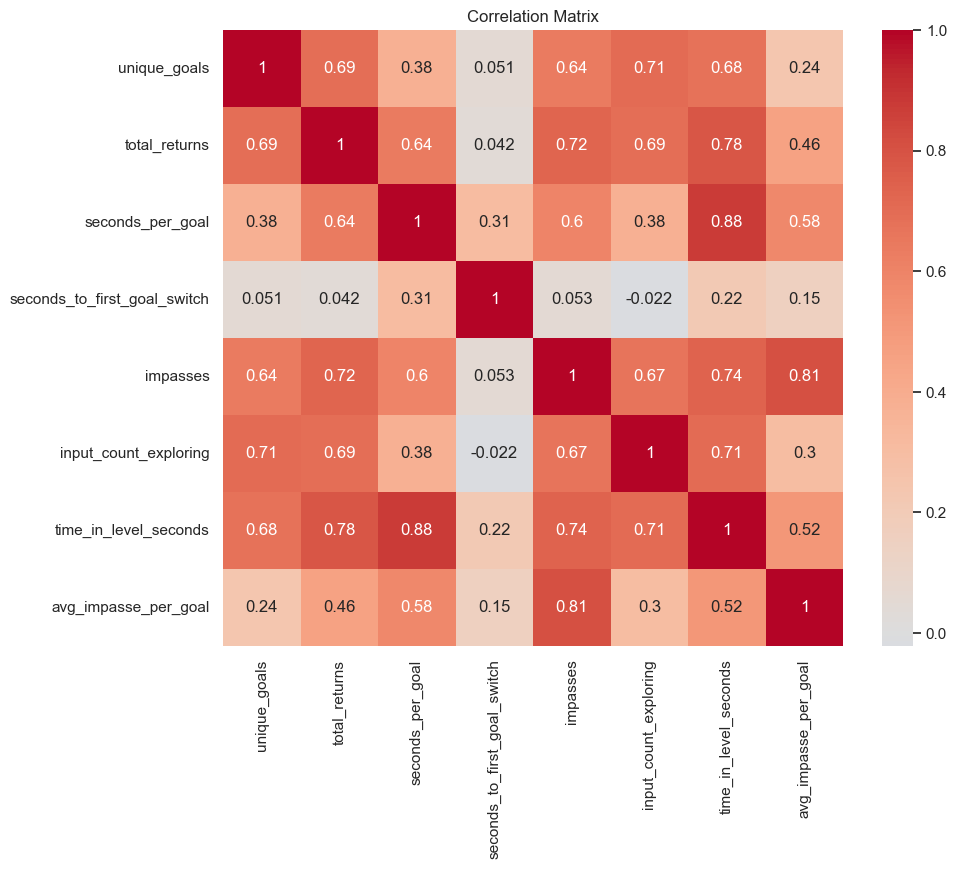

In [91]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Keep Relevant Features

In [92]:
data_numeric = df_numeric.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_numeric

,total_returns,seconds_to_first_goal_switch
0,2,13.416
1,0,8.816
2,11,17.533
3,3,9.300
4,0,15.067
...,...,...
143,4,7.817
144,3,2.500
145,15,14.133
147,20,8.283


In [93]:
# data_numeric = remove_outliers(data_numeric)
# data_numeric

In [94]:
data_numeric.describe()

,total_returns,seconds_to_first_goal_switch
count,131.000000,131.000000
mean,4.541985,13.788244
std,4.886810,8.546895
min,0.000000,0.383000
25%,1.000000,7.591500
50%,3.000000,11.633000
75%,7.000000,17.275000
max,23.000000,39.350000


#### Normalize Data

In [95]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

### Model

#### Hierarchical Clustering

In [96]:
linked = linkage(data_scaled, method='ward')

#### Visualize Dendrogram

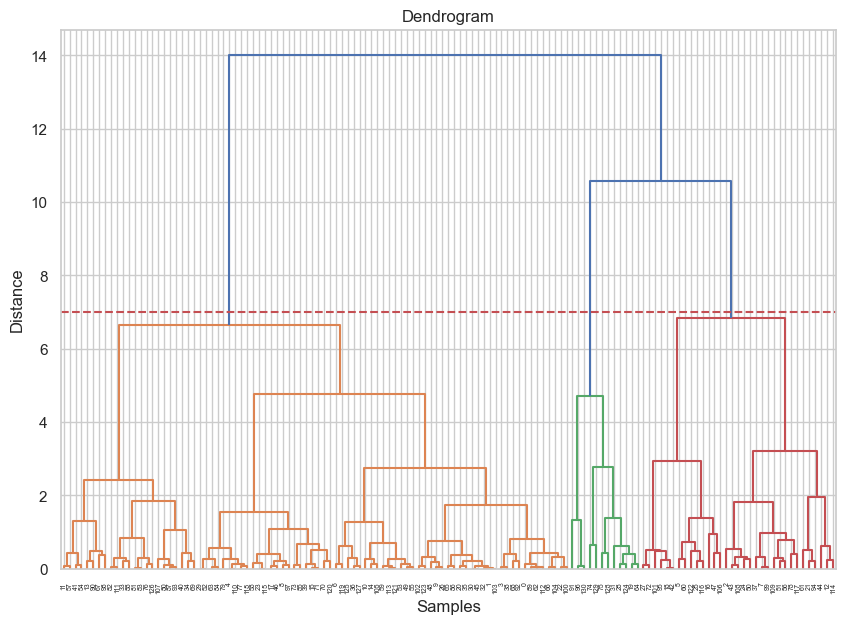

In [97]:
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', no_labels=False)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=7, color='r', linestyle='--')  # Check threshold
plt.show()

### Evaluate Threshold for Clusters 

In [98]:
# Function to calculate silhouette score for different thresholds
def evaluate_silhouette(linked, data_scaled, thresholds):
    best_threshold = None
    best_score = -1
    scores = []
    
    for threshold in thresholds:
        labels = fcluster(linked, threshold, criterion='distance')
        score = silhouette_score(data_scaled, labels)
        scores.append((threshold, score))
        
        if score > best_score:
            best_score = score
            best_threshold = threshold
    
    return best_threshold, best_score, scores

# Define a range of thresholds to evaluate
thresholds = np.arange(1, 10, 0.5)

# Evaluate silhouette score for different thresholds
best_threshold, best_score, scores = evaluate_silhouette(linked, data_scaled, thresholds)

print(f"Best Threshold: {best_threshold}")
print(f"Best Silhouette Score: {best_score}")

# Display scores for each threshold
for threshold, score in scores:
    print(f"Threshold: {threshold}, Silhouette Score: {score}")

Best Threshold: 7.0
Best Silhouette Score: 0.44822808200254577
Threshold: 1.0, Silhouette Score: 0.4233271675565187
Threshold: 1.5, Silhouette Score: 0.3855823255299853
Threshold: 2.0, Silhouette Score: 0.3493290315334695
Threshold: 2.5, Silhouette Score: 0.35067082854220294
Threshold: 3.0, Silhouette Score: 0.364621233682626
Threshold: 3.5, Silhouette Score: 0.3556776024137533
Threshold: 4.0, Silhouette Score: 0.3556776024137533
Threshold: 4.5, Silhouette Score: 0.3556776024137533
Threshold: 5.0, Silhouette Score: 0.37861402719770076
Threshold: 5.5, Silhouette Score: 0.37861402719770076
Threshold: 6.0, Silhouette Score: 0.37861402719770076
Threshold: 6.5, Silhouette Score: 0.37861402719770076
Threshold: 7.0, Silhouette Score: 0.44822808200254577
Threshold: 7.5, Silhouette Score: 0.44822808200254577
Threshold: 8.0, Silhouette Score: 0.44822808200254577
Threshold: 8.5, Silhouette Score: 0.44822808200254577
Threshold: 9.0, Silhouette Score: 0.44822808200254577
Threshold: 9.5, Silhouette 

### Label Data w/ Clusters @ Threshold

In [99]:
# Form flat clusters using the specified threshold
threshold = 7
clusters = fcluster(linked, t=threshold, criterion='distance')

# Add the cluster labels to the original dataset
data['cluster'] = clusters

# Display the first few rows of the updated dataset
data.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal,cluster
0,2,2,2,18.233000,13.416,7,110,82.466,7.000000,1
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000,1
2,12,7,11,12.821286,17.533,17,230,148.016,1.666667,3
3,13,6,3,18.163833,9.300,52,365,281.800,8.200000,1
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000,1


### Clean Data

In [100]:
data_export = data.drop(columns=['input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster
0,2,2,13.416,1
1,6,0,8.816,1
2,12,11,17.533,3
3,13,3,9.300,1
4,22,0,15.067,1
...,...,...,...,...
143,248,4,7.817,1
144,251,3,2.500,1
145,252,15,14.133,2
147,255,20,8.283,2


### Explore Clusters

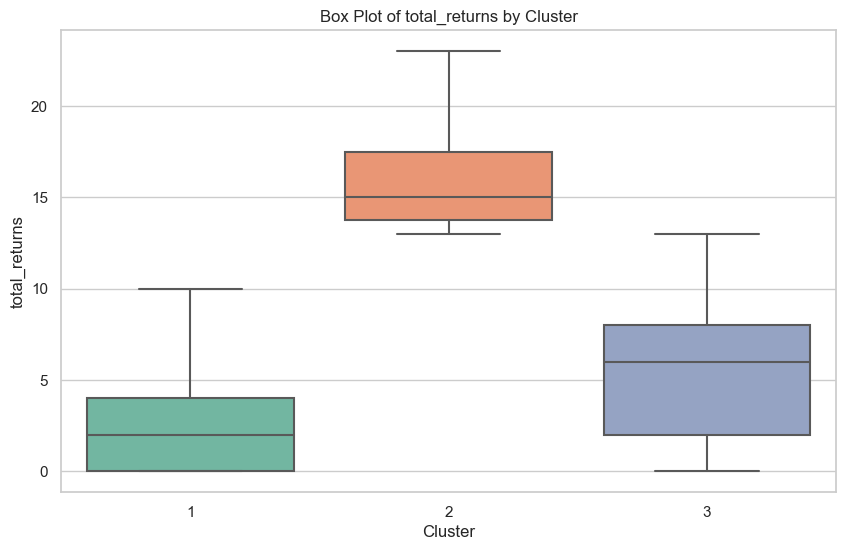

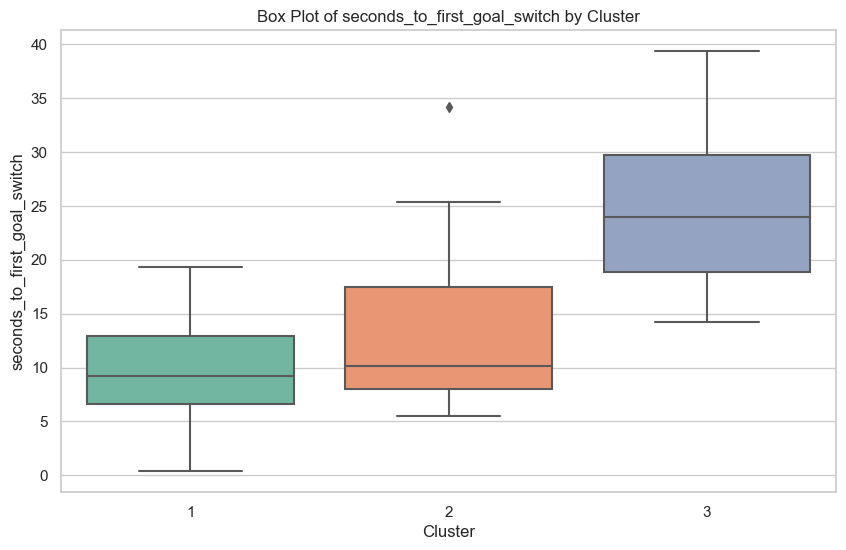

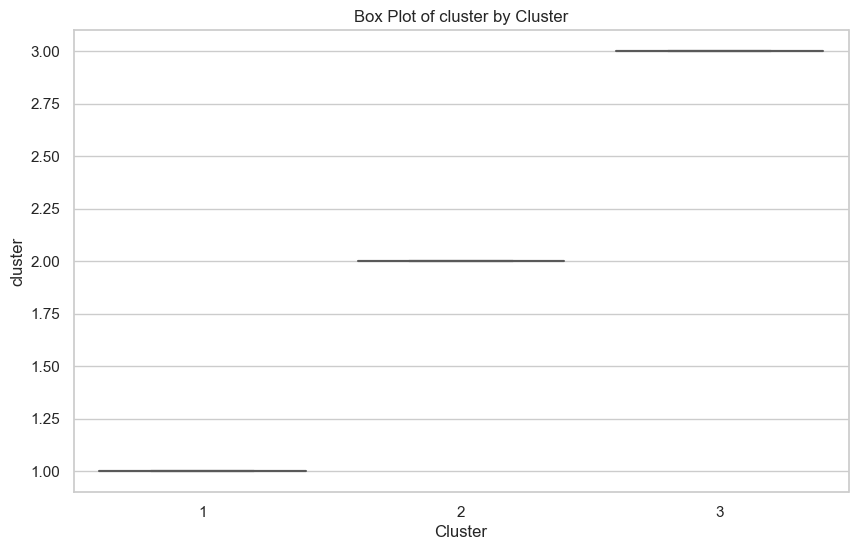

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Function to create box plots for each numeric column grouped by 'Cluster'
def plot_boxplots(data_export, numeric_columns):
    for column in numeric_columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data_export, x='cluster', y=column, palette='Set2')
        plt.title(f'Box Plot of {column} by Cluster')
        plt.xlabel('Cluster')
        plt.ylabel(column)
        plt.show()


# List of numeric columns
numeric_columns = data_export.columns[data_export.dtypes != 'object'].tolist()
numeric_columns.remove('ID')  # Exclude ID as it's not a relevant numeric column for analysis


# Plot box plots
plot_boxplots(data_export, numeric_columns)

In [102]:
# Define the mapping
cluster_mapping = {
    1: 'low-returns_fast-reframe',
    2: 'high-returns_fast-reframe',
    3: 'low-returns_slow-reframe'
    # Add more mappings as needed
}

# Add a new column based on the 'cluster' column
data_export['cluster-category-bw'] = data_export['cluster'].map(cluster_mapping)

In [103]:
# data_export['cluster-category'] = data_export['cluster-category'] + "_bw"

In [104]:
data_export

,ID,total_returns,seconds_to_first_goal_switch,cluster,cluster-category-bw
0,2,2,13.416,1,low-returns_fast-reframe
1,6,0,8.816,1,low-returns_fast-reframe
2,12,11,17.533,3,low-returns_slow-reframe
3,13,3,9.300,1,low-returns_fast-reframe
4,22,0,15.067,1,low-returns_fast-reframe
...,...,...,...,...,...
143,248,4,7.817,1,low-returns_fast-reframe
144,251,3,2.500,1,low-returns_fast-reframe
145,252,15,14.133,2,high-returns_fast-reframe
147,255,20,8.283,2,high-returns_fast-reframe


### Export Data

In [105]:
data_export.to_csv('/Users/baselhussein/Projects/impossible_goals/agg/data/bw_clusters.csv', index=False)